In [1]:
from google.colab import files
import zipfile, os

# Upload dataset.zip
uploaded = files.upload()

# Extract
with zipfile.ZipFile('dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

# Verify
dataset_path = '/content/brain_tumor_dataset'
for cls in os.listdir(dataset_path):
    count = len(os.listdir(os.path.join(dataset_path, cls)))
    print(f'  Class: {cls} -> {count} images')

Saving dataset.zip to dataset.zip
  Class: no -> 98 images
  Class: yes -> 155 images


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, Model
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.preprocessing import image as keras_image

print('TensorFlow version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
img_size   = 224
batch_size = 32
epochs     = 10

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

class_labels = {v: k for k, v in train_generator.class_indices.items()}
print('Class mapping:', class_labels)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Class mapping: {0: 'no', 1: 'yes'}


In [4]:
model = models.Sequential([
    # Block 1
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(224,224,3), name='conv1'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(128, (3,3), activation='relu', name='conv2'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(256, (3,3), activation='relu', name='conv3'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Classifier
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(2, activation='softmax')
], name='BrainTumorCNN')

optimizer = SGD(learning_rate=0.001, momentum=0.9)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "BrainTumorCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 222, 222, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 111, 111, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 109, 109, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 54, 54, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 52, 52, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 26, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 173056)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    22,151,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,522,370 (85.92 MB)

 Trainable params: 22,522,370 (85.92 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs,
    validation_data=val_generator,
    validation_steps=val_generator.samples // batch_size
)

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.5789 - loss: 0.6727 - val_accuracy: 0.5938 - val_loss: 0.6419
Epoch 2/10
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.5625 - loss: 0.6963

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 463ms/step - accuracy: 0.5625 - loss: 0.6963 - val_accuracy: 0.5625 - val_loss: 0.6494
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 509ms/step - accuracy: 0.6250 - loss: 0.6185 - val_accuracy: 0.7188 - val_loss: 0.6126
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.5455 - loss: 0.6201 - val_accuracy: 0.8750 - val_loss: 0.5883
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 479ms/step - accuracy: 0.7076 - loss: 0.6146 - val_accuracy: 0.6562 - val_loss: 0.6084
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 246ms/step - accuracy: 0.6562 - loss: 0.6385 - val_accuracy: 0.6562 - val_loss: 0.5424
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 648ms/step - accuracy: 0.6257 - loss: 0.7109 - val_accuracy: 0.6875 - val_loss: 0.5851
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step - accuracy: 0.7188 - loss: 0.5673 - val_accuracy: 0.6875 - val_loss: 0.6200
Epoch 9/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 481ms/step - accuracy: 0.6667 - loss: 0.5947 - val_accuracy: 0.6562 - val_loss: 0.6047
Epo

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.6600 - loss: 0.6061
Validation Loss     : 0.6061
Validation Accuracy : 66.00%


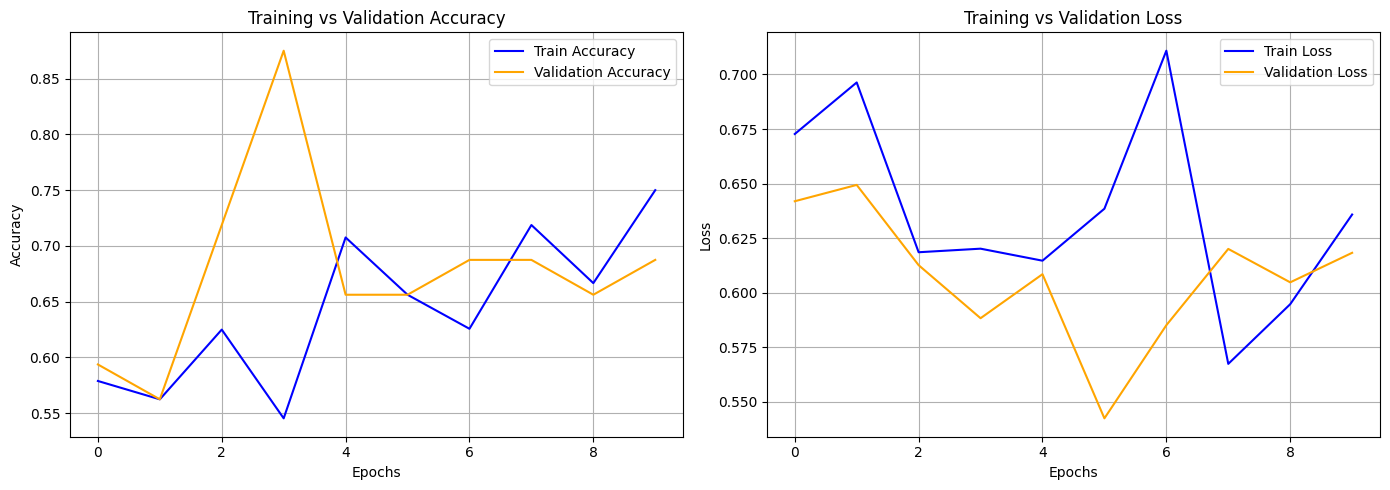

In [6]:
loss, accuracy = model.evaluate(val_generator)
print(f'Validation Loss     : {loss:.4f}')
print(f'Validation Accuracy : {accuracy*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy',      color='blue')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[0].set_title('Training vs Validation Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'],     label='Train Loss',      color='blue')
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='orange')
axes[1].set_title('Training vs Validation Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

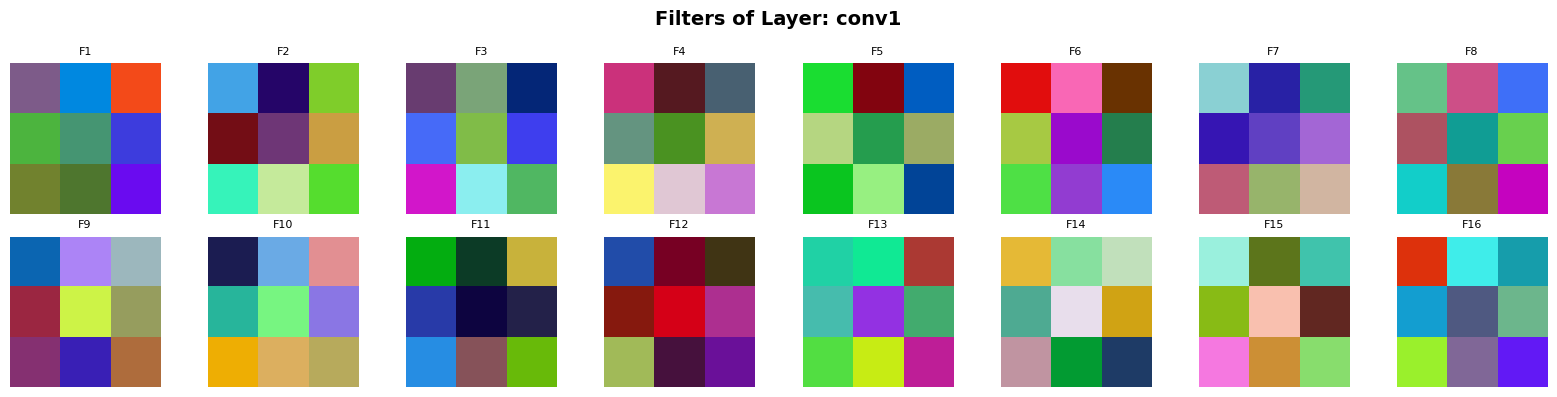

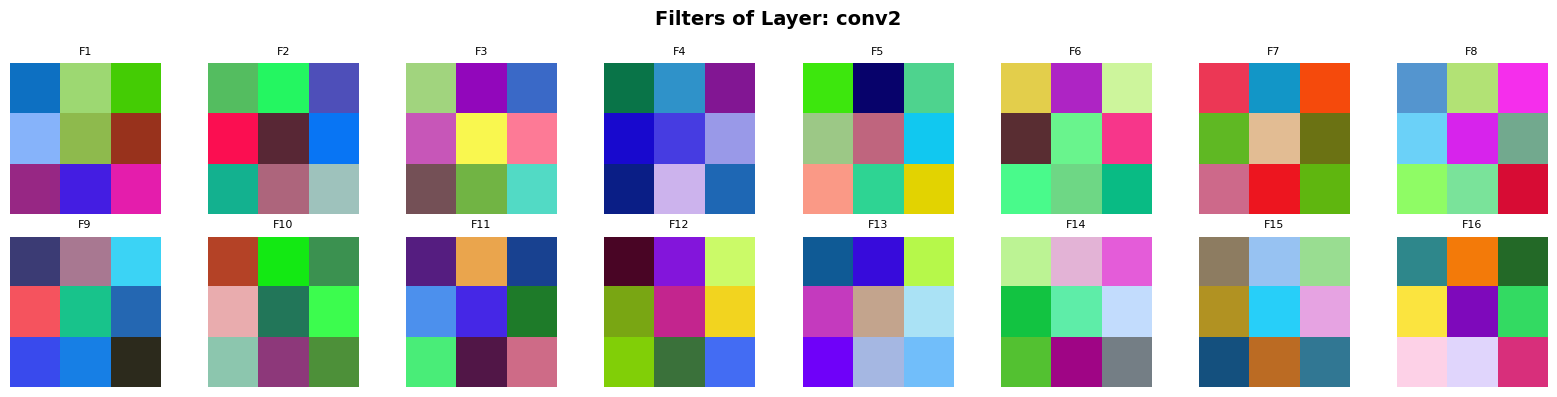

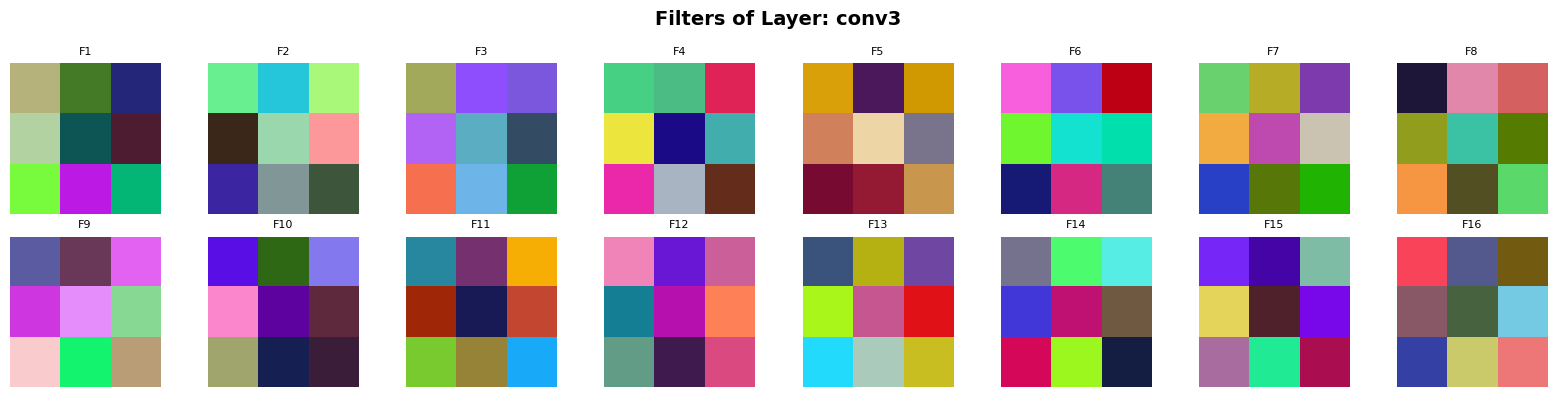

In [7]:
def visualize_filters(model, layer_name, num_filters=16):
    """Visualize convolutional filters (weights) of a given layer."""
    layer = model.get_layer(layer_name)
    filters, _ = layer.get_weights()

    f_min, f_max = filters.min(), filters.max()
    filters = (filters - f_min) / (f_max - f_min + 1e-8)

    num_filters = min(num_filters, filters.shape[-1])
    cols = 8
    rows = (num_filters + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    fig.suptitle(f'Filters of Layer: {layer_name}', fontsize=14, fontweight='bold')

    for i in range(rows * cols):
        ax = axes[i // cols][i % cols] if rows > 1 else axes[i % cols]
        if i < num_filters:
            f = filters[:, :, :, i]
            if f.shape[2] >= 3:
                ax.imshow(f[:, :, :3])
            else:
                ax.imshow(f[:, :, 0], cmap='viridis')
            ax.set_title(f'F{i+1}', fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

for layer_name in ['conv1', 'conv2', 'conv3']:
    visualize_filters(model, layer_name, num_filters=16)

Sample image: /content/brain_tumor_dataset/yes/Y6.jpg


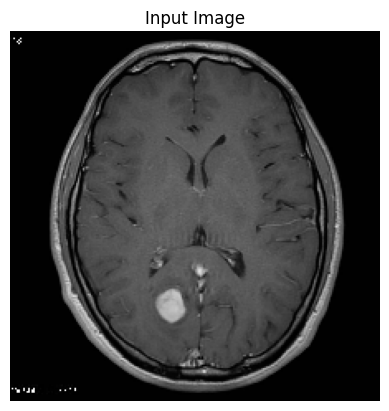

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 744ms/step


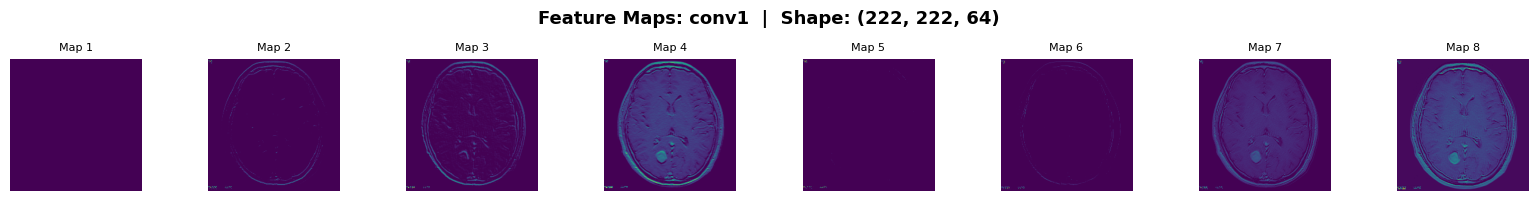

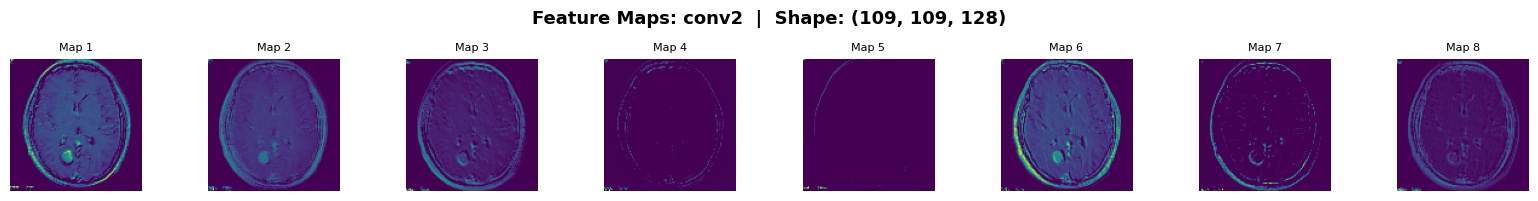

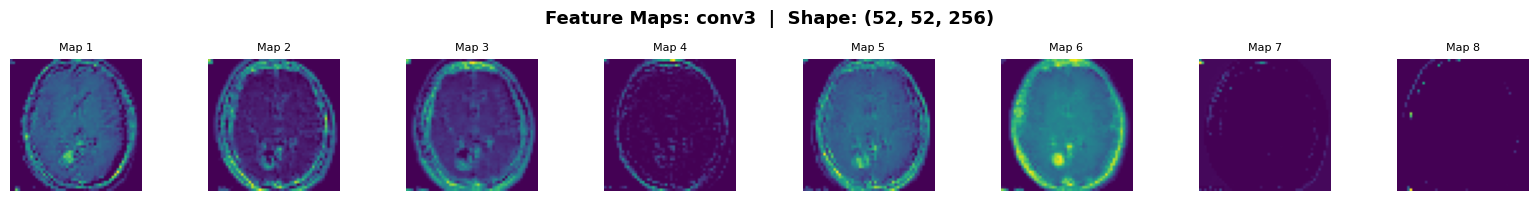

In [8]:
def visualize_feature_maps(model, img_array, layer_names, num_features=8):
    """Show activation feature maps — FIXED for Keras 3 Sequential models."""

    # ✅ FIX: Rebuild functional model by tracing through layers manually
    inp = tf.keras.Input(shape=(224, 224, 3))
    x = inp
    feature_outputs = []
    captured_names  = []

    for layer in model.layers:
        x = layer(x)
        if layer.name in layer_names:
            feature_outputs.append(x)
            captured_names.append(layer.name)

    activation_model = Model(inputs=inp, outputs=feature_outputs)
    activations = activation_model.predict(img_array)

    if not isinstance(activations, list):
        activations = [activations]

    for layer_name, activation in zip(captured_names, activations):
        n    = min(num_features, activation.shape[-1])
        cols = 8
        rows = (n + cols - 1) // cols

        fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
        fig.suptitle(f'Feature Maps: {layer_name}  |  Shape: {activation.shape[1:]}',
                     fontsize=13, fontweight='bold')

        for i in range(rows * cols):
            ax = axes[i // cols][i % cols] if rows > 1 else axes[i % cols]
            if i < n:
                ax.imshow(activation[0, :, :, i], cmap='viridis')
                ax.set_title(f'Map {i+1}', fontsize=8)
            ax.axis('off')

        plt.tight_layout()
        plt.show()


# Use one sample image from dataset
sample_img_path = os.path.join(dataset_path, 'yes',
                               os.listdir(os.path.join(dataset_path, 'yes'))[0])

sample_img = keras_image.load_img(sample_img_path, target_size=(224, 224))
sample_arr = keras_image.img_to_array(sample_img) / 255.0
sample_arr = np.expand_dims(sample_arr, axis=0)

print('Sample image:', sample_img_path)
plt.imshow(sample_img)
plt.title('Input Image')
plt.axis('off')
plt.show()

visualize_feature_maps(model, sample_arr, ['conv1', 'conv2', 'conv3'], num_features=8)

=== Grad-CAM on TUMOR image ===


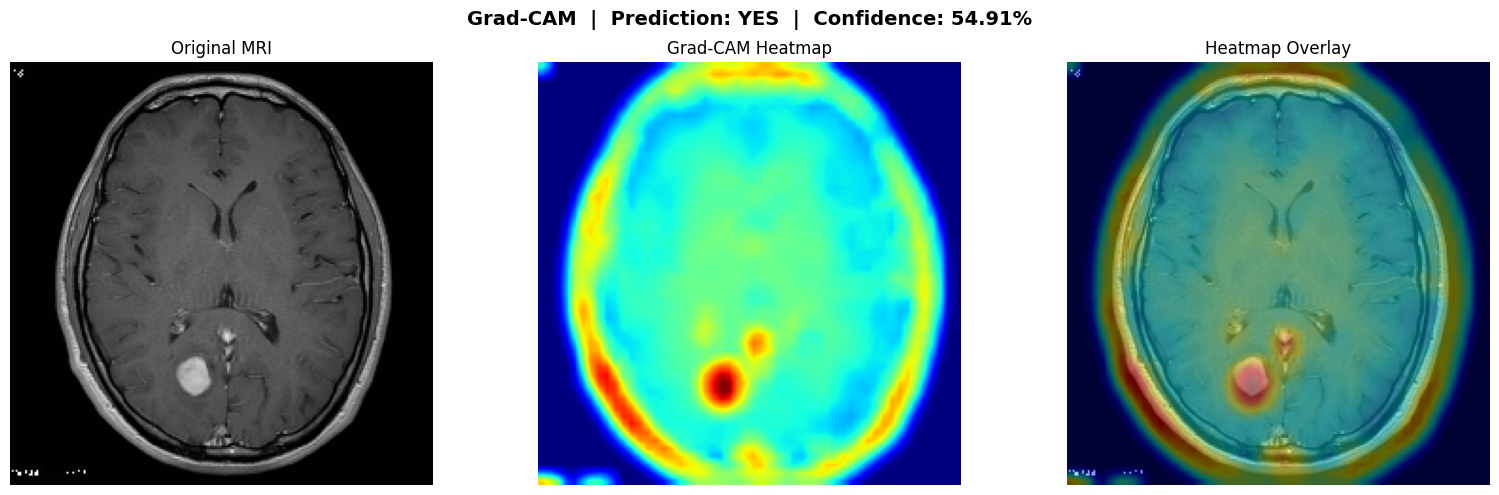

=== Grad-CAM on NO TUMOR image ===


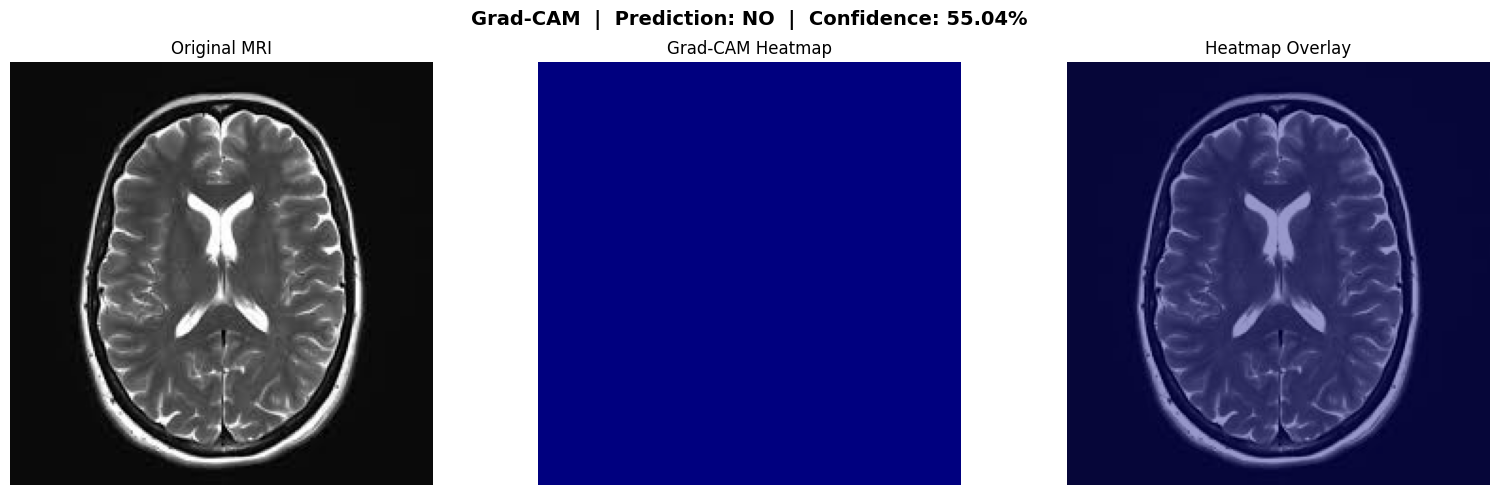

('no',
 np.float32(55.039925),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32))

In [9]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name='conv3'):
    """Generate Grad-CAM heatmap — FIXED for Keras 3 Sequential models."""

    # ✅ FIX: Build grad model by tracing layers manually
    inp = tf.keras.Input(shape=(224, 224, 3))
    x = inp
    conv_out = None

    for layer in model.layers:
        x = layer(x)
        if layer.name == last_conv_layer_name:
            conv_out = x

    grad_model = Model(inputs=inp, outputs=[conv_out, x])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index    = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads       = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), predictions.numpy()


def overlay_gradcam(original_img_path, model, class_labels, alpha=0.4):
    """Overlay Grad-CAM heatmap on the original image."""
    img     = keras_image.load_img(original_img_path, target_size=(224, 224))
    img_arr = keras_image.img_to_array(img) / 255.0
    img_4d  = np.expand_dims(img_arr, axis=0)

    heatmap, predictions = make_gradcam_heatmap(img_4d, model)

    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_colored, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    original_uint8 = np.uint8(255 * img_arr)
    superimposed   = cv2.addWeighted(original_uint8, 1 - alpha,
                                     heatmap_colored, alpha, 0)

    pred_class = class_labels[np.argmax(predictions[0])]
    confidence = np.max(predictions[0]) * 100

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'Grad-CAM  |  Prediction: {pred_class.upper()}  '
                 f'|  Confidence: {confidence:.2f}%', fontsize=14, fontweight='bold')

    axes[0].imshow(img);             axes[0].set_title('Original MRI');     axes[0].axis('off')
    axes[1].imshow(heatmap_resized, cmap='jet'); axes[1].set_title('Grad-CAM Heatmap'); axes[1].axis('off')
    axes[2].imshow(superimposed);    axes[2].set_title('Heatmap Overlay');  axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    return pred_class, confidence, heatmap_resized


print('=== Grad-CAM on TUMOR image ===')
yes_img = os.path.join(dataset_path, 'yes',
                       os.listdir(os.path.join(dataset_path, 'yes'))[0])
overlay_gradcam(yes_img, model, class_labels)

print('=== Grad-CAM on NO TUMOR image ===')
no_img = os.path.join(dataset_path, 'no',
                      os.listdir(os.path.join(dataset_path, 'no'))[0])
overlay_gradcam(no_img, model, class_labels)

=== Tumor Localization ===


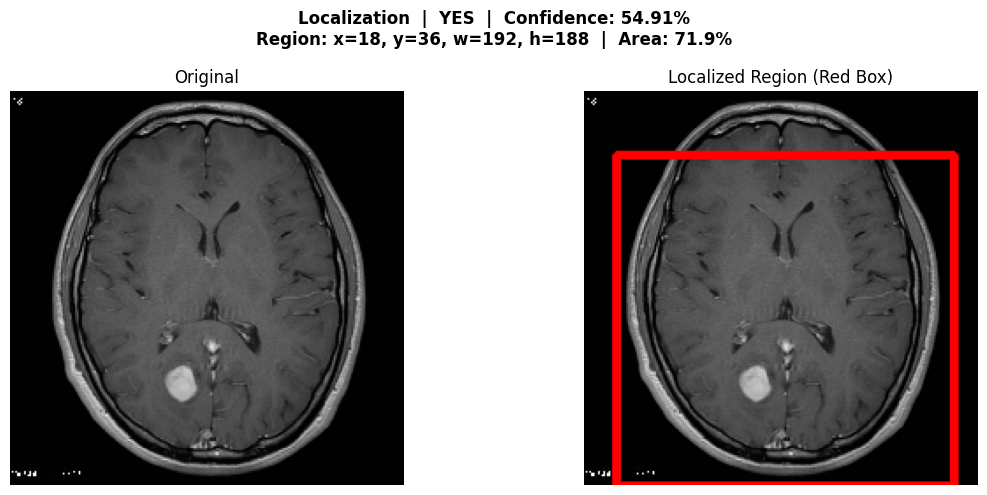

In [10]:
def localize_tumor(img_path, model, class_labels, threshold=0.5):
    """Draw bounding box around the high-activation (tumor) region."""
    img     = keras_image.load_img(img_path, target_size=(224, 224))
    img_arr = keras_image.img_to_array(img) / 255.0
    img_4d  = np.expand_dims(img_arr, axis=0)

    heatmap, predictions = make_gradcam_heatmap(img_4d, model)
    pred_class = class_labels[np.argmax(predictions[0])]
    confidence = np.max(predictions[0]) * 100

    heatmap_resized = cv2.resize(heatmap, (224, 224))

    binary_map = (heatmap_resized > threshold).astype(np.uint8)
    contours, _ = cv2.findContours(binary_map, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)

    original_uint8 = np.uint8(255 * img_arr).copy()
    area_pct = 0

    if contours and pred_class == 'yes':
        largest  = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest)
        cv2.rectangle(original_uint8, (x, y), (x+w, y+h), (255, 0, 0), 3)
        area_pct = (w * h) / (224 * 224) * 100
        loc_info = f'Region: x={x}, y={y}, w={w}, h={h}  |  Area: {area_pct:.1f}%'
    else:
        loc_info = 'No significant tumor region detected'

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f'Localization  |  {pred_class.upper()}  |  Confidence: {confidence:.2f}%\n{loc_info}',
                 fontsize=12, fontweight='bold')

    axes[0].imshow(img);            axes[0].set_title('Original');                  axes[0].axis('off')
    axes[1].imshow(original_uint8); axes[1].set_title('Localized Region (Red Box)'); axes[1].axis('off')

    plt.tight_layout()
    plt.show()


print('=== Tumor Localization ===')
localize_tumor(yes_img, model, class_labels)

Upload an MRI image for full analysis:


Saving test.jpg.jpeg to test.jpg.jpeg


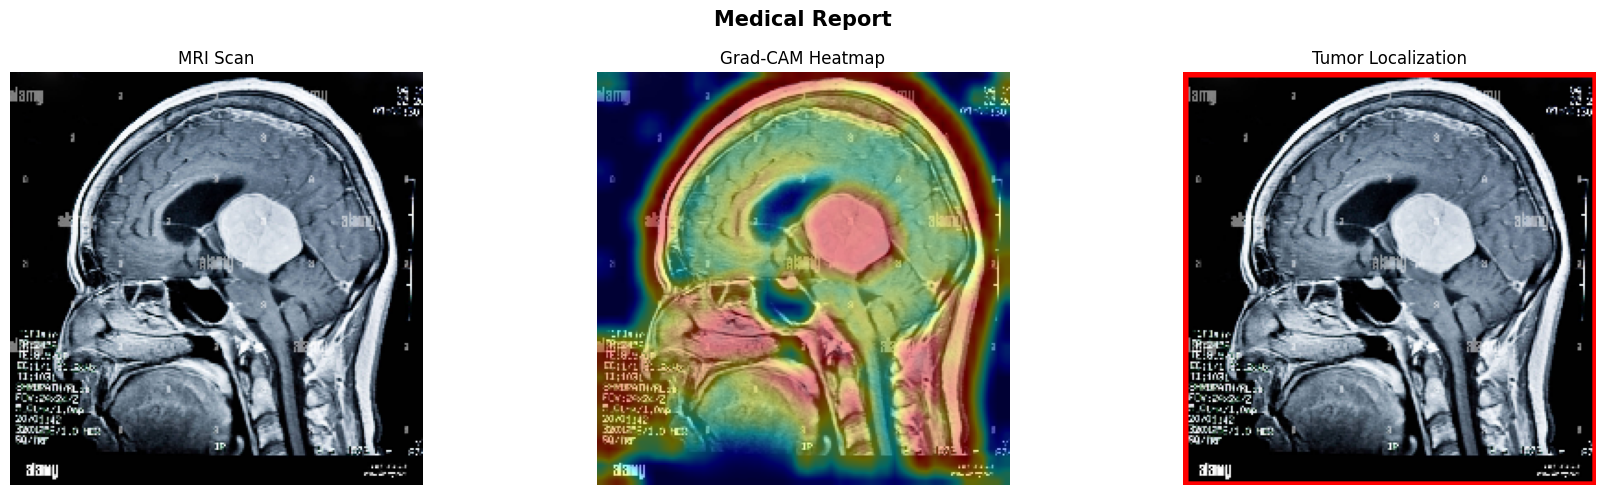


         🏥  MEDICAL INTERPRETATION REPORT
  Diagnosis       : YES
  Confidence      : 64.40%
  Tumor Area      : ~100.0% of scan

  🔴 TUMOR DETECTED
  The model identified abnormal tissue in the MRI.
  The red heatmap region highlights the suspected
  tumor area. Please consult a radiologist.
  Risk Level      : LOW CONFIDENCE - re-evaluate

  ⚠️  NOTE: This is an AI-based screening tool.
  Always confirm with a certified medical professional.


In [11]:
def medical_report(img_path, model, class_labels):
    """Full prediction + Grad-CAM + Localization + Medical Interpretation."""
    img     = keras_image.load_img(img_path, target_size=(224, 224))
    img_arr = keras_image.img_to_array(img) / 255.0
    img_4d  = np.expand_dims(img_arr, axis=0)

    heatmap, predictions = make_gradcam_heatmap(img_4d, model)
    pred_class = class_labels[np.argmax(predictions[0])]
    confidence = np.max(predictions[0]) * 100

    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_colored, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    original_uint8 = np.uint8(255 * img_arr)
    superimposed   = cv2.addWeighted(original_uint8, 0.6, heatmap_colored, 0.4, 0)

    # Localization
    binary_map = (heatmap_resized > 0.5).astype(np.uint8)
    contours, _ = cv2.findContours(binary_map, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    loc_img  = original_uint8.copy()
    area_pct = 0
    if contours and pred_class == 'yes':
        largest = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest)
        cv2.rectangle(loc_img, (x, y), (x+w, y+h), (255, 0, 0), 3)
        area_pct = (w * h) / (224 * 224) * 100

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].imshow(img);          axes[0].set_title('MRI Scan');           axes[0].axis('off')
    axes[1].imshow(superimposed); axes[1].set_title('Grad-CAM Heatmap');   axes[1].axis('off')
    axes[2].imshow(loc_img);      axes[2].set_title('Tumor Localization'); axes[2].axis('off')
    plt.suptitle('Medical Report', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Medical Interpretation
    print('\n' + '='*55)
    print('         🏥  MEDICAL INTERPRETATION REPORT')
    print('='*55)
    print(f'  Diagnosis       : {pred_class.upper()}')
    print(f'  Confidence      : {confidence:.2f}%')

    if pred_class == 'yes':
        print(f'  Tumor Area      : ~{area_pct:.1f}% of scan')
        print('\n  🔴 TUMOR DETECTED')
        print('  The model identified abnormal tissue in the MRI.')
        print('  The red heatmap region highlights the suspected')
        print('  tumor area. Please consult a radiologist.')
        if confidence >= 85:
            print('  Risk Level      : HIGH (>=85% confidence)')
        elif confidence >= 65:
            print('  Risk Level      : MODERATE (65-84% confidence)')
        else:
            print('  Risk Level      : LOW CONFIDENCE - re-evaluate')
    else:
        print('\n  🟢 NO TUMOR DETECTED')
        print('  The model found no significant anomalies in')
        print('  the MRI scan. The brain appears normal.')
        if confidence >= 85:
            print('  Confidence Level: HIGH - likely healthy')
        else:
            print('  Confidence Level: MODERATE - further review advised')

    print('\n  ⚠️  NOTE: This is an AI-based screening tool.')
    print('  Always confirm with a certified medical professional.')
    print('='*55)


# Upload your own MRI image
from google.colab import files
print('Upload an MRI image for full analysis:')
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

medical_report(img_path, model, class_labels)